In [1]:
library(tidyverse)
library(plotly)

Warning message:
“package ‘tidyverse’ was built under R version 3.5.2”── Attaching packages ──────────────────────────────────────────────────────────────────────────── tidyverse 1.3.0 ──
✔ ggplot2 3.3.2     ✔ purrr   0.3.4
✔ tibble  3.0.4     ✔ dplyr   1.0.2
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.0
Warning message:
“package ‘stringr’ was built under R version 3.5.2”Warning message:
“package ‘forcats’ was built under R version 3.5.2”── Conflicts ─────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



In [5]:
head(iris)

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa


# Plotly-R的绘图逻辑

在R中，plotly的绘图方式相比于Python中更加简洁，**绘图接口类似于`plotly.express`**，不需要像`plotly.graph_objects`这种更加底层的设置方式。

plotly-R绘图的一些逻辑见官方文档 [R Figure Reference](https://plotly.com/r/reference/index/)

用于绘图的主要有如下三个函数。

+ `plot_ly()`：用来绘制基础图形  
`plot_ly(
     data = data.frame(), ..., type = NULL, name, color, colors = NULL, stroke, strokes = NULL, alpha = NULL, 
     size, sizes = c(10, 100), span, spans = c(1, 20), symbol, symbols = NULL, linetype, linetypes = NULL, split, frame,
     width = NULL, height = NULL, source = "A"
)`
  + `...`，指定绘图变量，形如`x=, y=`；**同时根据绘制图形的不同，还需要传入对应图形的其他参数也放在这里**。
  + `type`，指定绘图类型，比如 'scatter', 'bar', 'box', 'heatmap', 'histogram', 'histogram2d', 'histogram2dcontour', 'contour'等。
  + `name`，
  + `color`，指定映射到颜色属性的变量——这里的颜色是指**填充的颜色**；如果要**使用颜色名称**，需要使用 `I('red')` 这种形式。
  + `colors`，使用 **调色板** 或者 **十六进制的#RRGGBB** 格式来指定颜色。
  + `stroke`，类似于`color`，不过设置的是 **边框** 的颜色。
  + `strokes`，类似于`colors`，也是设置的边框颜色。
  + `alpha`，设置透明度。
  + `size`，指定映射到大小属性的变量；如果设定为数值，应当使用`I(30)`。
  + `sizes`，
  + `linetype`，
  + `linetypes`，
  + `symbol`，
  + `symbols`，
  + `width`和`height`，图形的宽和高，单位为像素。
  
  返回一个 plotly 对象。

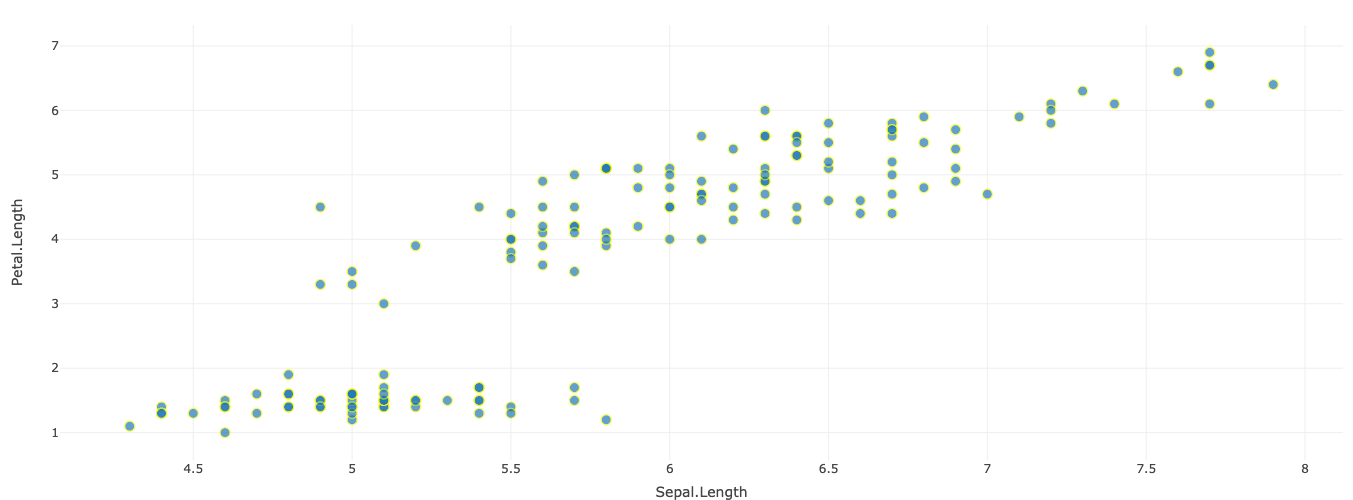

In [34]:
fig <- plot_ly(data = iris, x = ~Sepal.Length, y = ~Petal.Length, type='scatter', mode='markers', stroke=I('yellow'), size=I(50)
               ,width=800, height=500)
fig

+ `add_trace()`：用来在已有图形上添加新的图形。  
它有许多具体形式的函数，如下：
  + `add_trace(p, ..., data = NULL, inherit = TRUE)`,
  + `add_markers(p, x = NULL, y = NULL, z = NULL, ..., data = NULL, inherit = TRUE)`
  + `add_lines(p, x = NULL, y = NULL, z = NULL, ..., data = NULL, inherit = TRUE)`
  + `add_histogram(p, x = NULL, y = NULL, ..., data = NULL, inherit = TRUE)`
  + `add_text(p, x = NULL, y = NULL, z = NULL, text = NULL, ..., data = NULL, inherit = TRUE)`
  
  还有其他的一些函数，具体看帮助文档。

+ `layout()`：用来设置图形外观，比如标题属性，横纵坐标轴属性，图例属性，图形外边距属性，这些属性包括字体，颜色，尺寸等。

具体的控制细节和能够设置的属性见官方文档 [R Figure Reference: `layout`](https://plotly.com/r/reference/layout/)。

---

# 具体绘图

## 散点图和线图